In [73]:
# To ignore warnings
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

from sklearn import metrics

%matplotlib inline

## Loading the data
We can now load the dataset into pandas using the read_csv() function. This converts the CSV file into a Pandas dataframe.

In [74]:
football = pd.read_csv("Data/final_data.csv")


### Viewing the dataframe
We can get a quick sense of the size of our dataset by using the shape method. This returns a tuple with the number of rows and columns in the dataset.

In [75]:
football.shape

(10754, 22)

In [76]:
football.columns

Index(['player', 'team', 'name', 'position', 'height', 'age', 'appearance',
       'goals', 'assists', 'yellow cards', 'second yellow cards', 'red cards',
       'goals conceded', 'clean sheets', 'minutes played', 'days_injured',
       'games_injured', 'award', 'current_value', 'highest_value',
       'position_encoded', 'winger'],
      dtype='object')

In [77]:
pd.set_option('display.max_columns', None)
football.head(1)

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,second yellow cards,red cards,goals conceded,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger
0,/david-de-gea/profil/spieler/59377,Manchester United,David de Gea,Goalkeeper,189.0,32.0,104,0.0,0.0,0.009585,0.0,0.0,1.217252,0.335463,9390,42,5,13,15000000,70000000,1,0


## 1. Data Profiling:
Data profiling is a comprehensive process of examining the data available in an existing dataset and collecting statistics and information about that data.

In [78]:
football.describe(include="object")


,player,team,name,position
count,10754,10754,10754,10754
unique,10754,374,10584,16
top,/david-de-gea/profil/spieler/59377,Daejeon Hana Citizen,Paulinho,Defender Centre-Back
freq,1,46,6,1821


In [79]:
football.describe(include="integer")

,appearance,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger
count,10754.000000,10754.000000,10754.000000,10754.000000,10754.000000,1.075400e+04,1.075400e+04,10754.000000,10754.000000
mean,36.407011,2470.789381,117.961689,15.826297,1.960759,3.622971e+06,6.152606e+06,2.713223,0.307513
std,26.526541,2021.703271,175.206827,23.383606,3.743936,9.095410e+06,1.338988e+07,0.986356,0.461485
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000,0.000000
25%,12.000000,660.000000,0.000000,0.000000,0.000000,3.000000e+05,4.500000e+05,2.000000,0.000000
50%,35.000000,2101.500000,37.000000,5.000000,1.000000,8.000000e+05,1.500000e+06,3.000000,0.000000
75%,59.000000,3968.000000,181.000000,24.000000,2.000000,3.000000e+06,5.000000e+06,4.000000,1.000000
max,107.000000,9510.000000,2349.000000,339.000000,92.000000,1.800000e+08,2.000000e+08,4.000000,1.000000


In [80]:
football.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10754 entries, 0 to 10753
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player               10754 non-null  object 
 1   team                 10754 non-null  object 
 2   name                 10754 non-null  object 
 3   position             10754 non-null  object 
 4   height               10754 non-null  float64
 5   age                  10754 non-null  float64
 6   appearance           10754 non-null  int64  
 7   goals                10754 non-null  float64
 8   assists              10754 non-null  float64
 9   yellow cards         10754 non-null  float64
 10  second yellow cards  10754 non-null  float64
 11  red cards            10754 non-null  float64
 12  goals conceded       10754 non-null  float64
 13  clean sheets         10754 non-null  float64
 14  minutes played       10754 non-null  int64  
 15  days_injured         10754 non-null 

In [81]:
football['position'].unique()

array(['Goalkeeper', 'Defender Centre-Back', 'Defender Left-Back',
       'Defender Right-Back', 'midfield-DefensiveMidfield',
       'midfield-CentralMidfield', 'midfield-AttackingMidfield',
       'Attack-LeftWinger', 'Attack-RightWinger', 'Attack Centre-Forward',
       'midfield-RightMidfield', 'midfield-LeftMidfield',
       'Attack-SecondStriker', 'midfield', 'Attack', 'Defender'],
      dtype=object)

In [82]:
football[football['position']=="Defender Centre-Back"]

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,second yellow cards,red cards,goals conceded,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger
3,/lisandro-martinez/profil/spieler/480762,Manchester United,Lisandro Martínez,Defender Centre-Back,175.0,25.0,82,0.028090,0.056180,0.224719,0.0000,0.000000,0.0,0.0,6408,175,22,9,50000000,50000000,2,0
4,/raphael-varane/profil/spieler/164770,Manchester United,Raphaël Varane,Defender Centre-Back,191.0,30.0,63,0.017889,0.017889,0.053667,0.0000,0.000000,0.0,0.0,5031,238,51,21,40000000,80000000,2,0
5,/harry-maguire/profil/spieler/177907,Manchester United,Harry Maguire,Defender Centre-Back,194.0,30.0,68,0.037799,0.000000,0.302394,0.0189,0.000000,0.0,0.0,4762,148,27,1,25000000,70000000,2,0
6,/victor-lindelof/profil/spieler/184573,Manchester United,Victor Lindelöf,Defender Centre-Back,187.0,28.0,70,0.000000,0.032901,0.115153,0.0000,0.000000,0.0,0.0,5471,95,19,10,15000000,35000000,2,0
7,/phil-jones/profil/spieler/117996,Manchester United,Phil Jones,Defender Centre-Back,185.0,31.0,8,0.000000,0.000000,0.216346,0.0000,0.000000,0.0,0.0,416,932,169,7,2000000,20000000,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10703,/alexandar-popovic/profil/spieler/904309,Adelaide United,Alexandar Popovic,Defender Centre-Back,185.0,20.0,31,0.032991,0.065982,0.329912,0.0000,0.000000,0.0,0.0,2728,0,0,0,250000,250000,2,0
10704,/lachlan-barr/profil/spieler/519906,Adelaide United,Lachlan Barr,Defender Centre-Back,189.0,28.0,35,0.096809,0.032270,0.258157,0.0000,0.000000,0.0,0.0,2789,0,0,0,200000,200000,2,0
10729,/marcelo/profil/spieler/52920,Western Sydney Wanderers,Marcelo,Defender Centre-Back,191.0,36.0,47,0.091347,0.022837,0.251205,0.0000,0.045674,0.0,0.0,3941,26,2,5,800000,9000000,2,0
10730,/tomislav-mrcela/profil/spieler/206941,Western Sydney Wanderers,Tomislav Mrcela,Defender Centre-Back,193.0,32.0,47,0.045068,0.022534,0.157737,0.0000,0.022534,0.0,0.0,3994,27,5,0,400000,1000000,2,0


The process of profiling differs slightly for categorical and numerical variables due to their inherent differences.

**The two main types of data are:**
- Quantitative (numerical) data
- Qualitative (categorical) data

### Data Quality Checks
Data quality checks involve the process of ensuring that the data is accurate, complete, consistent, relevant, and reliable.


**Here are typical steps involved in checking data quality:**

#### 1. Reliability:
Evaluate the data's source and collection process to determine its trustworthiness.

In [83]:
# The dataset was sourced from Kaggle Football Players' Transfer Fee Prediction Dataset (https://www.kaggle.com/datasets/khanghunhnguyntrng/football-players-transfer-fee-prediction-dataset/data)

#### 2. Timeliness:
Ensure the data is up-to-date and reflective of the current situation or the period of interest for the analysis.

In [84]:
# A dataset of football players was collected for the 2021-2022 and 2022-2023 seasons.

#### 3. Consistency:

Confirm that the data is consistent within the dataset and across multiple data sources. For example, the same data point should not have different values in different places.


In [85]:
# The use of a single dataset guarantees consistency from the outset

#### 4. Relevance:
Assess whether the data is appropriate and applicable for the intended analysis. Data that is not relevant can skew results and lead to incorrect conclusions.

**Key considerations for relevance include:**

> 1. Sample Appropriateness: Confirm that your data sample aligns with your analysis objectives. For instance, utilizing data from the Northern region will not yield accurate insights for the Western region of the Kingdom.
>
> 2. Variable Selection: Any column will not be relevant for our analysis, we can get rid of these using the drop() method. We will set the “axis” argument to 1 since we’re dealing with columns, and set the “inplace” argument to True to make the change permanent.


In [86]:
# 1. Sample Appropriateness: "Based on the data characteristics, the sample is appropriate for this analysis."
# 2. Variable Selection: "The needed variables are relevant to the analysis.

In [87]:
football.head(3)

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,second yellow cards,red cards,goals conceded,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger
0,/david-de-gea/profil/spieler/59377,Manchester United,David de Gea,Goalkeeper,189.0,32.0,104,0.0,0.0,0.009585,0.0,0.0,1.217252,0.335463,9390,42,5,13,15000000,70000000,1,0
1,/jack-butland/profil/spieler/128899,Manchester United,Jack Butland,Goalkeeper,196.0,30.0,15,0.0,0.0,0.069018,0.0,0.0,1.242331,0.207055,1304,510,58,1,1500000,22000000,1,0
2,/tom-heaton/profil/spieler/34130,Manchester United,Tom Heaton,Goalkeeper,188.0,37.0,4,0.0,0.0,0.000000,0.0,0.0,0.616438,0.924658,292,697,84,4,600000,6000000,1,0


In [88]:
# the link to the Transfermarkt page contains player data. Please add a prefix "www.transfermarkt.com
football['player'].unique()

array(['/david-de-gea/profil/spieler/59377',
       '/jack-butland/profil/spieler/128899',
       '/tom-heaton/profil/spieler/34130', ...,
       '/nathanael-blair/profil/spieler/1023268',
       '/zachary-sapsford/profil/spieler/703657',
       '/alexander-badolato/profil/spieler/957230'], dtype=object)

#### 5. Uniqueness:
Check for and remove duplicate records to prevent skewed analysis results.


In [89]:
# check if there is duplicated rows in dataset
football[football.duplicated(keep= False)]

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,second yellow cards,red cards,goals conceded,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger


In [90]:
# I noticed that some name players are duplicated in the dataset with differences in columns values
# because there is players with same name
football[football['name'].duplicated(keep=False)].sort_values(by='name')

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,second yellow cards,red cards,goals conceded,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger
2206,/aaron-ramsey/profil/spieler/50057,OGC Nice,Aaron Ramsey,midfield-CentralMidfield,186.0,32.0,52,0.094970,0.158284,0.189940,0.0,0.000000,0.0,0.0,2843,342,38,9,3000000,45000000,3,0
5597,/aaron-ramsey/profil/spieler/646658,Middlesbrough FC,Aaron Ramsey,midfield-AttackingMidfield,181.0,20.0,55,0.393873,0.253204,0.084401,0.0,0.000000,0.0,0.0,3199,0,0,0,5000000,5000000,3,0
9104,/abdulaziz-majrashi/profil/spieler/444714,Al-Tai,Abdulaziz Majrashi,Defender Right-Back,162.0,31.0,39,0.000000,0.000000,0.358387,0.0,0.000000,0.0,0.0,2009,27,0,0,150000,200000,2,1
9079,/abdulaziz-majrashi/profil/spieler/500321,Damac FC,Abdulaziz Majrashi,midfield-DefensiveMidfield,173.0,27.0,43,0.000000,0.037578,0.112735,0.0,0.037578,0.0,0.0,2395,0,0,0,75000,150000,3,0
9295,/abdullah-al-yousef/profil/spieler/478535,Al-Adalah FC,Abdullah Al-Yousef,Defender Left-Back,174.0,33.0,4,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,176,0,0,0,25000,125000,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3679,/wanderson/profil/spieler/316067,América Futebol Clube (MG),Wanderson,Defender Centre-Back,186.0,32.0,4,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,360,0,0,0,300000,1750000,2,0
3751,/wesley/profil/spieler/964580,CR Flamengo,Wesley,Defender Right-Back,173.0,19.0,10,0.000000,0.110701,0.000000,0.0,0.000000,0.0,0.0,813,0,0,1,150000,150000,2,1
3497,/wesley/profil/spieler/674732,Cruzeiro Esporte Clube,Wesley,Attack-LeftWinger,175.0,24.0,10,0.456081,0.000000,0.456081,0.0,0.000000,0.0,0.0,592,105,31,5,6000000,7000000,4,1
4203,/ze-carlos/profil/spieler/617679,Gil Vicente FC,Zé Carlos,Defender Right-Back,177.0,24.0,47,0.000000,0.105541,0.343008,0.0,0.000000,0.0,0.0,3411,0,0,1,800000,1500000,2,1


In [91]:
# The player link is unique, making it a key that should not be duplicated
football[football['player'].duplicated(keep=False)].sort_values(by='player')

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,second yellow cards,red cards,goals conceded,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger


In [92]:
# go to delete duplicates columns

#### 6. Completeness:
Ensure that no critical data is missing. This might mean checking for null values or required fields that are empty.

We will start by checking the dataset for missing or null values. For this, we can use the isna() method which returns a dataframe of boolean values indicating if a field is null or not. To group all missing values by column, we can include the sum() method.

In [93]:
#Display number missing values per column

In [94]:
# check if there any missing values per column
football.isnull().sum().sort_values(ascending = False)

player                 0
team                   0
position_encoded       0
highest_value          0
current_value          0
award                  0
games_injured          0
days_injured           0
minutes played         0
clean sheets           0
goals conceded         0
red cards              0
second yellow cards    0
yellow cards           0
assists                0
goals                  0
appearance             0
age                    0
height                 0
position               0
name                   0
winger                 0
dtype: int64

In [95]:
# go to clean them

#### 7. Check Accuracy:

Verify that the data is correct and precise. This could involve comparing data samples with known sources or using validation rules.

**The process includes:**
1. Validating the appropriateness of data types for the dataset.
2. Identifying outliers  using established validation  rule

In [96]:
football.head(1)

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,second yellow cards,red cards,goals conceded,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger
0,/david-de-gea/profil/spieler/59377,Manchester United,David de Gea,Goalkeeper,189.0,32.0,104,0.0,0.0,0.009585,0.0,0.0,1.217252,0.335463,9390,42,5,13,15000000,70000000,1,0


In [97]:
football.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10754 entries, 0 to 10753
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player               10754 non-null  object 
 1   team                 10754 non-null  object 
 2   name                 10754 non-null  object 
 3   position             10754 non-null  object 
 4   height               10754 non-null  float64
 5   age                  10754 non-null  float64
 6   appearance           10754 non-null  int64  
 7   goals                10754 non-null  float64
 8   assists              10754 non-null  float64
 9   yellow cards         10754 non-null  float64
 10  second yellow cards  10754 non-null  float64
 11  red cards            10754 non-null  float64
 12  goals conceded       10754 non-null  float64
 13  clean sheets         10754 non-null  float64
 14  minutes played       10754 non-null  int64  
 15  days_injured         10754 non-null 

In [98]:
football.dtypes

player                  object
team                    object
name                    object
position                object
height                 float64
age                    float64
appearance               int64
goals                  float64
assists                float64
yellow cards           float64
second yellow cards    float64
red cards              float64
goals conceded         float64
clean sheets           float64
minutes played           int64
days_injured             int64
games_injured            int64
award                    int64
current_value            int64
highest_value            int64
position_encoded         int64
winger                   int64
dtype: object

In [99]:
categorical_features = ['team', 'position']
numeric_features = ['height', 'age', 'appearance',"goals" ,"assists" ,"yellow cards","second yellow cards","red cards","goals conceded","clean sheets" ,"minutes played" , "days_injured" ,"games_injured","award","current_value" , "highest_value" ,"position_encoded" ,"winger"]

In [100]:
for i in categorical_features:
   print (football[i].value_counts())

team
Daejeon Hana Citizen      46
Jeonbuk Hyundai Motors    46
FC Seoul                  45
Gangwon FC                43
Daegu FC                  42
                          ..
FC Barcelona              22
Atlético de Madrid        22
CA Osasuna                22
Hatayspor                 12
Gaziantep FK               6
Name: count, Length: 374, dtype: int64
position
Defender Centre-Back          1821
Attack Centre-Forward         1353
Goalkeeper                    1229
midfield-CentralMidfield      1149
midfield-DefensiveMidfield     900
Defender Right-Back            867
Defender Left-Back             807
midfield-AttackingMidfield     769
Attack-RightWinger             717
Attack-LeftWinger              714
midfield-RightMidfield         102
midfield-LeftMidfield          100
midfield                        75
Attack-SecondStriker            65
Attack                          53
Defender                        33
Name: count, dtype: int64


In [101]:
football_model = football.copy()

In [102]:
football_model.drop(columns=["name","player"],inplace=True)

In [103]:
print("Categorical features: ", categorical_features)
print("Numerical features: ", numeric_features)

Categorical features:  ['team', 'position']
Numerical features:  ['height', 'age', 'appearance', 'goals', 'assists', 'yellow cards', 'second yellow cards', 'red cards', 'goals conceded', 'clean sheets', 'minutes played', 'days_injured', 'games_injured', 'award', 'current_value', 'highest_value', 'position_encoded', 'winger']


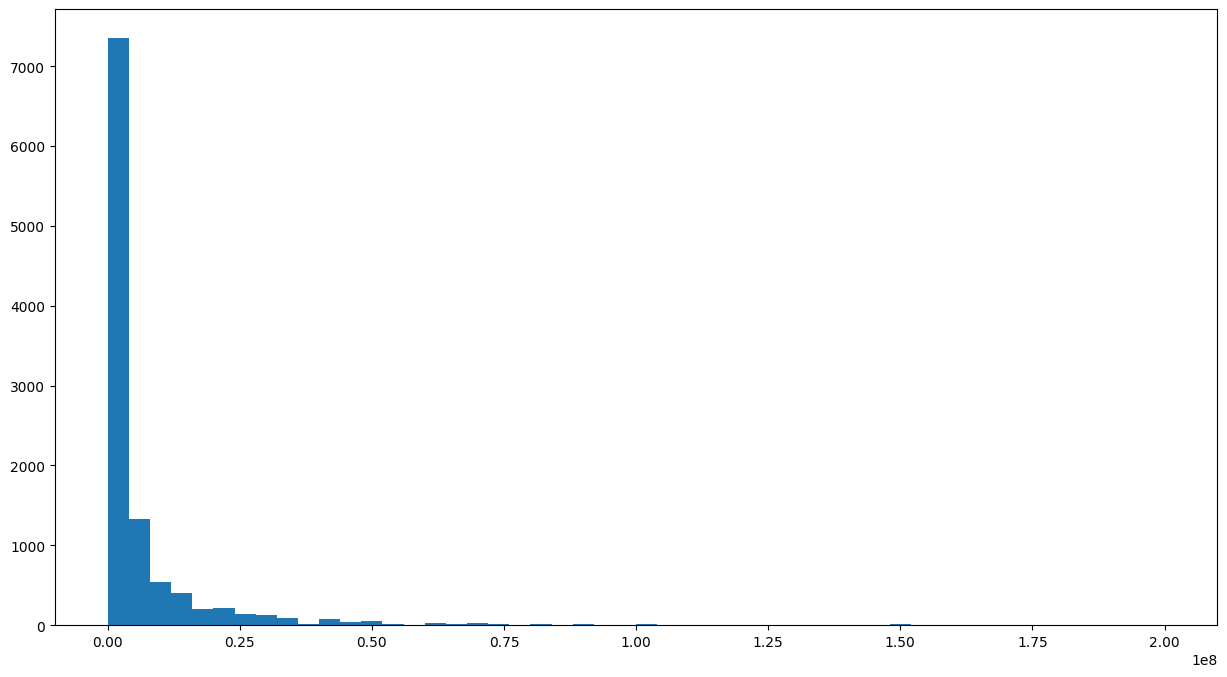

In [104]:
plt.figure(figsize=(15,8))
plt.hist(football_model['highest_value'], bins=50);
plt.show()

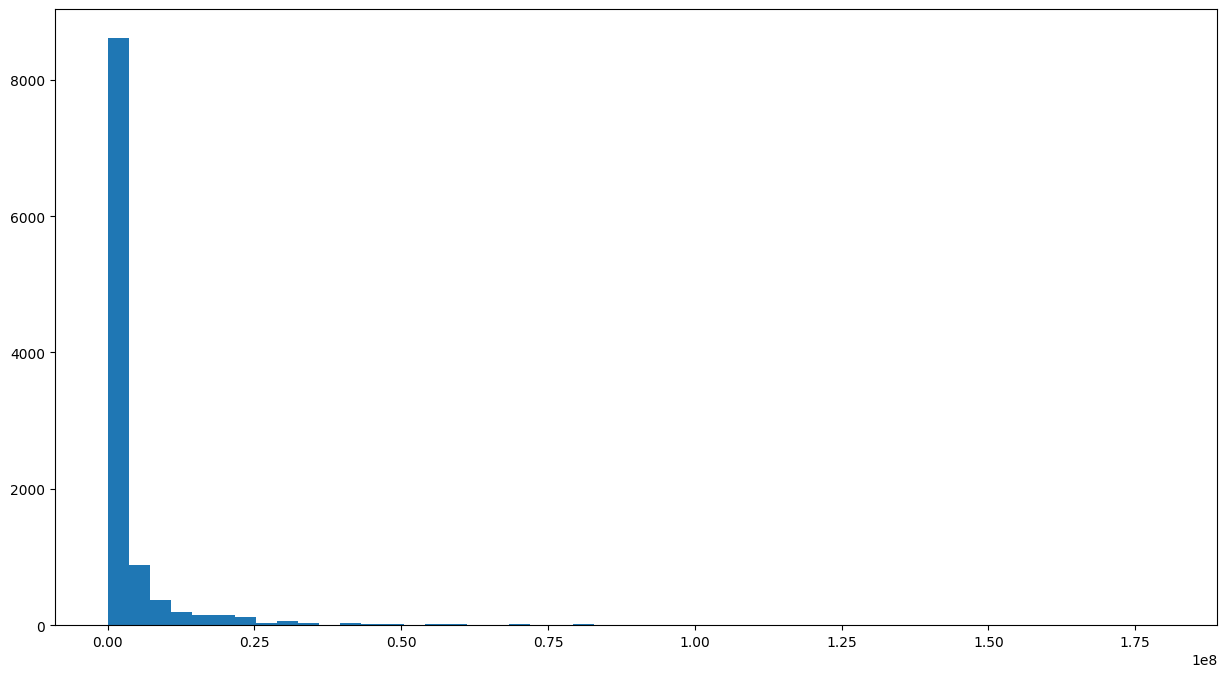

In [105]:
plt.figure(figsize=(15,8))
plt.hist(football_model['current_value'], bins=50);
plt.show()

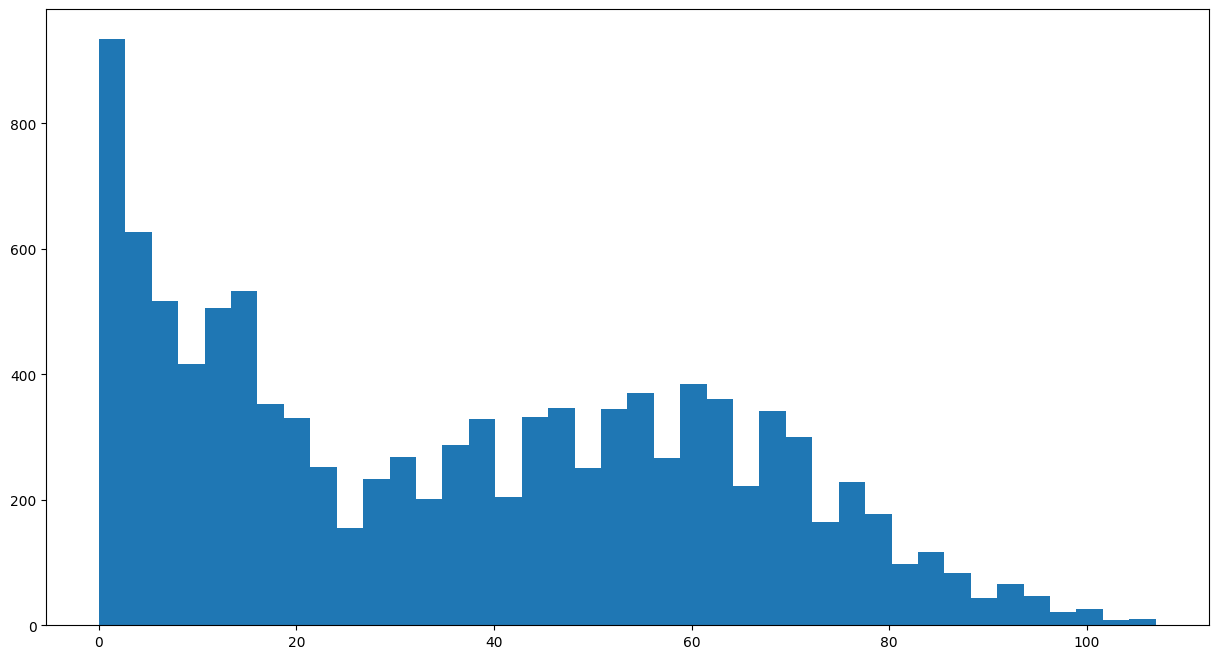

In [106]:
plt.figure(figsize=(15,8))
plt.hist(football_model['appearance'], bins=40);
plt.show()

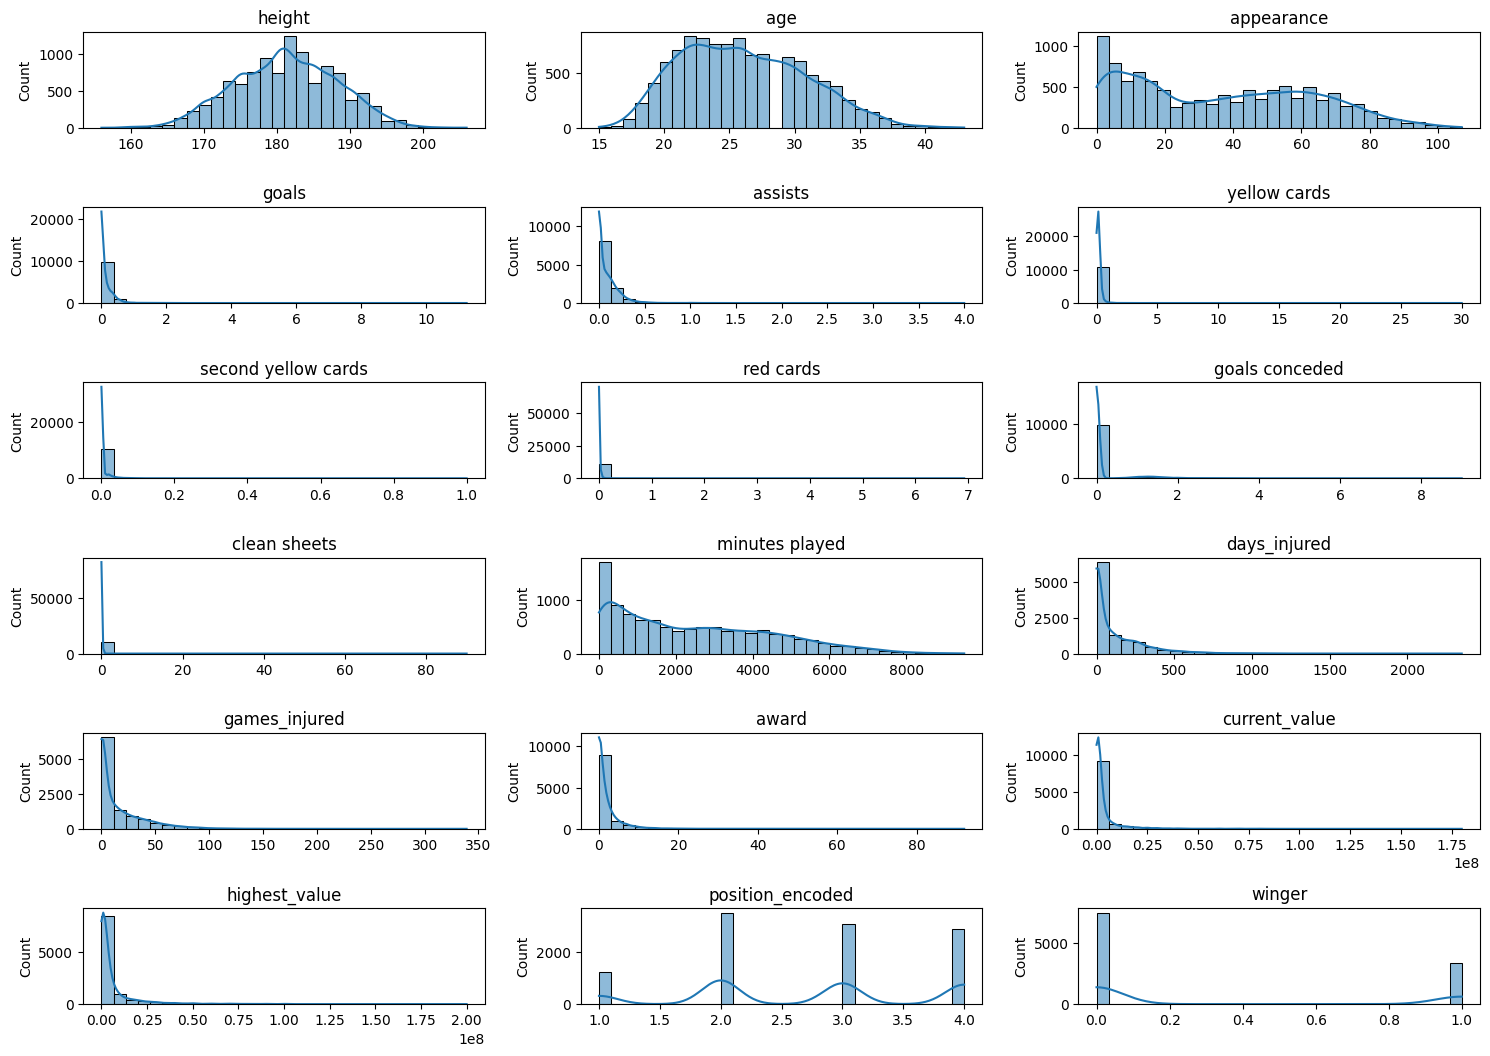

In [107]:
plt.figure(figsize=(15, 12))


num_features = len(numeric_features)
rows = (num_features // 3) + 1
cols = 3

for i, feature in enumerate(numeric_features, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(football[feature].dropna(), bins=30, kde=True)
    plt.title(feature)
    plt.xlabel("")

plt.tight_layout()
plt.show()

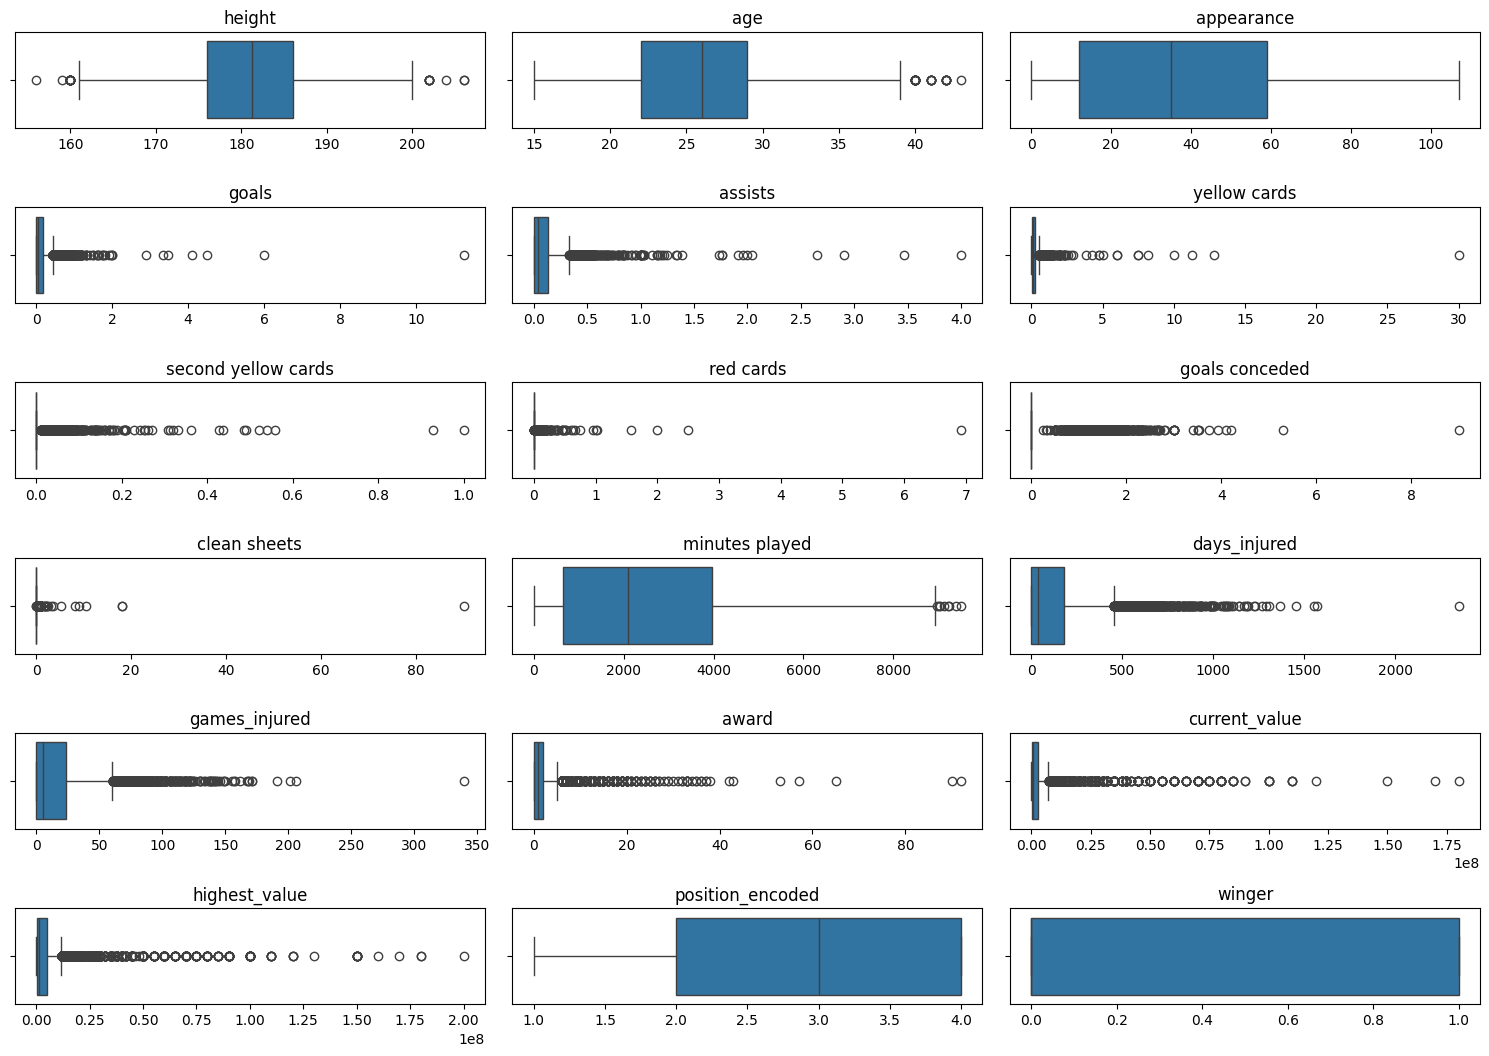

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(15, 12))


num_features = len(numeric_features)
rows = (num_features // 3) + 1
cols = 3

for i, feature in enumerate(numeric_features, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=football[feature])
    plt.title(feature)
    plt.xlabel("")

plt.tight_layout()
plt.show()


In [109]:
# Height & Age normally distributed with some expected outliers
# Minutes Played & Appearances the distribution reflects natural variations between starting players and substitutes
# Goals, Assists, Clean Sheets noticeable outliers, but expected since only a few players achieve exceptional stats
# Yellow & Red Cards some players have an unusually high number of cards
# Days Injured, Games Injured  some players have extremely long injury periods which could exceptional cases
# Current & Highest Value extreme values may result from market fluctuations

In [110]:
def plot_outliers(feature, threshold=0):
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=football[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()


    if feature not in football.columns:
        print(f"⚠️ Feature '{feature}' not found in dataset.")
        return


    outliers = football[football[feature] > threshold]
    print(f'\nTop {feature} Outliers:')
    print(outliers[['player', 'team', feature]].sort_values(by=feature, ascending=False))


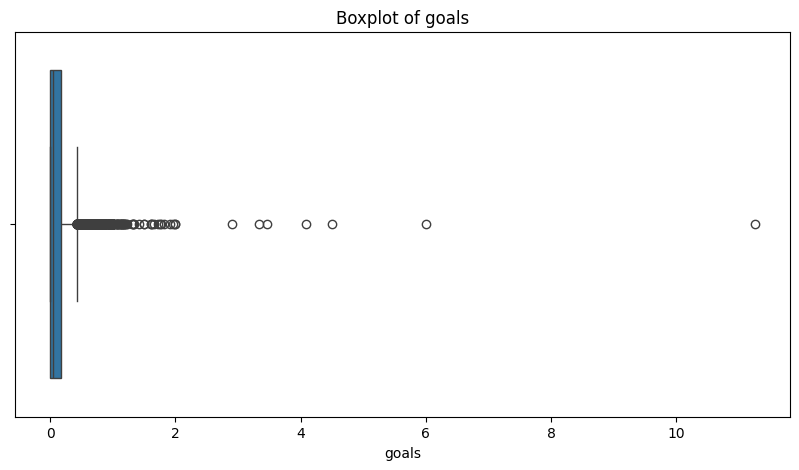


Top goals Outliers:
                                      player                             team  \
9239  /rakan-al-dosari/profil/spieler/998314                      Al-Raed SFC   
3799     /junior-moraes/profil/spieler/52915  Sport Club Corinthians Paulista   

      goals  
9239  11.25  
3799   6.00  


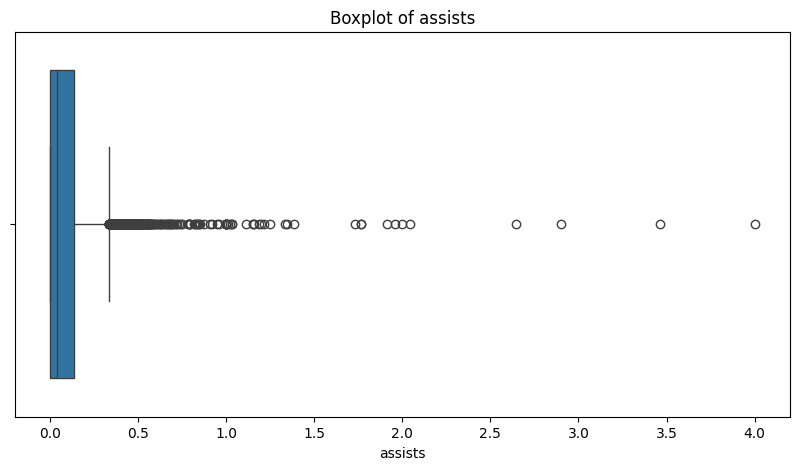


Top assists Outliers:
                                      player          team   assists
8387    /riki-harakawa/profil/spieler/212115  Cerezo Osaka  4.000000
6180  /denis-kovacevic/profil/spieler/672248  Istanbulspor  3.461538


In [111]:
plot_outliers('goals', 5)
plot_outliers('assists', 3)

In [112]:
#The results are natural because only a small percentage of players score or assist goals frequently.

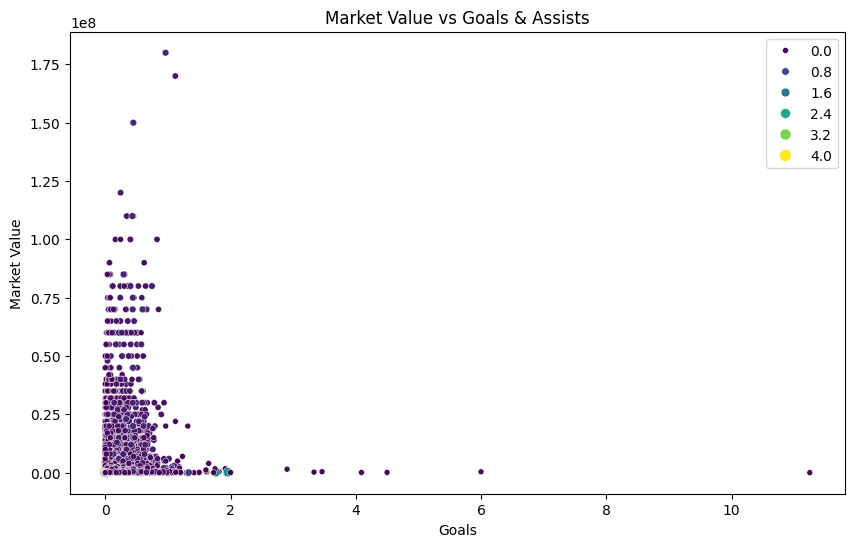

In [113]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=football, x='goals', y='current_value', hue='assists', size='assists', palette='viridis')
plt.title('Market Value vs Goals & Assists')
plt.xlabel('Goals')
plt.ylabel('Market Value')
plt.legend()
plt.show()

In [114]:
# Scoring goals is not the only factor influencing a player's market value, as we can see players with high market value despite scoring only a few goals

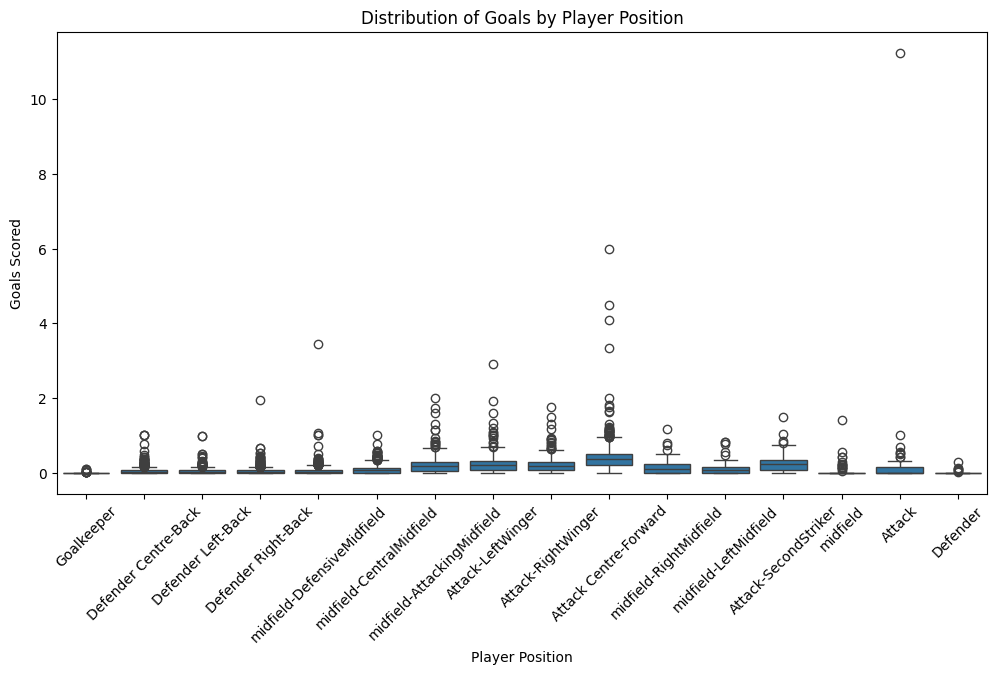

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))
sns.boxplot(x=football['position'], y=football['goals'])
plt.xlabel("Player Position")
plt.ylabel("Goals Scored")
plt.title("Distribution of Goals by Player Position")
plt.xticks(rotation=45)
plt.show()


In [116]:
avg_goals_by_position = football.groupby('position')['goals'].mean().sort_values(ascending=False)
print(avg_goals_by_position)


position
Attack Centre-Forward         0.377764
Attack                        0.321874
Attack-SecondStriker          0.273625
Attack-LeftWinger             0.225207
Attack-RightWinger            0.205473
midfield-AttackingMidfield    0.196806
midfield-RightMidfield        0.147148
midfield-LeftMidfield         0.114886
midfield-CentralMidfield      0.093751
midfield                      0.062398
midfield-DefensiveMidfield    0.056701
Defender Right-Back           0.045821
Defender Left-Back            0.043998
Defender Centre-Back          0.043040
Defender                      0.022536
Goalkeeper                    0.000411
Name: goals, dtype: float64


In [117]:
top_valued_players = football[[ "name" ,'team', 'current_value', 'highest_value', 'goals', 'assists']].sort_values(by='current_value', ascending=False).head(10)
print("Top 10 Most Valuable Players:")
print(top_valued_players)

Top 10 Most Valuable Players:
                   name                 team  current_value  highest_value  \
2644      Kylian Mbappé  Paris Saint-Germain      180000000      200000000   
453      Erling Haaland      Manchester City      170000000      170000000   
1521    Vinicius Junior          Real Madrid      150000000      150000000   
960     Jude Bellingham    Borussia Dortmund      120000000      120000000   
450          Phil Foden      Manchester City      110000000      110000000   
1017      Jamal Musiala        Bayern Munich      110000000      110000000   
474         Bukayo Saka           Arsenal FC      110000000      110000000   
1516  Federico Valverde          Real Madrid      100000000      100000000   
1523            Rodrygo          Real Madrid      100000000      100000000   
2023     Victor Osimhen           SSC Napoli      100000000      100000000   

         goals   assists  
2644  0.963082  0.433387  
453   1.118270  0.234699  
1521  0.448356  0.408502  
960

## 2. Data Cleaning:

Preliminary findings from data profiling can lead to cleaning the data by:
- Handling missing values
- Correcting errors.
- Dealing with outliers.

-------------------



In [118]:
def show_categories(df):
    for i, col in enumerate(df.select_dtypes(include=['object']).columns, start=1):
        print(f"{i}. {col} :\t {df[col].unique()}\n")



In [119]:
show_categories(football)

1. player :	 ['/david-de-gea/profil/spieler/59377'
 '/jack-butland/profil/spieler/128899' '/tom-heaton/profil/spieler/34130'
 ... '/nathanael-blair/profil/spieler/1023268'
 '/zachary-sapsford/profil/spieler/703657'
 '/alexander-badolato/profil/spieler/957230']

2. team :	 ['Manchester United' 'West Ham United' 'Leicester City' 'Aston Villa'
 'Wolverhampton Wanderers' 'Southampton FC' 'Brighton &amp; Hove Albion'
 'Everton FC' 'Nottingham Forest' 'Leeds United' 'Crystal Palace'
 'Fulham FC' 'AFC Bournemouth' 'Brentford FC' 'Liverpool FC'
 'Newcastle United' 'Manchester City' 'Arsenal FC' 'Tottenham Hotspur'
 'Chelsea FC' 'Borussia Mönchengladbach' 'VfL Wolfsburg'
 'TSG 1899 Hoffenheim' '1.FC Union Berlin' 'FC Augsburg' 'VfB Stuttgart'
 '1.FSV Mainz 05' '1.FC Köln' 'Hertha BSC' 'FC Schalke 04' 'VfL Bochum'
 'SV Werder Bremen' 'Eintracht Frankfurt' 'SC Freiburg'
 'Borussia Dortmund' 'Bayer 04 Leverkusen' 'Bayern Munich' 'RB Leipzig'
 'Real Sociedad' 'Villarreal CF' 'Real Betis Balompié' '

### Handling missing values:

In [120]:
# Dataset already clened

### Correcting errors

-------------------

In [121]:
# there is no erorr

### Dealing with outliers:

In [122]:
#  There is no need to remove any outliers
#  The high market values of top players are expected, and the variation in goals and assists is natural since only a few players consistently score or assist at high rates.
#  Removing outliers might lead to the loss of valuable insights.

## 3. Univariate Analysis: 

This involves examining single variables to understand their characteristics (distribution, central tendency, dispersion, and shape).

We calculate **numerical values** about the data that tells us about the distribution of the data. We also **draw graphs** showing visually how the data is distributed. **To answer the following questions about Features/characteristics of Data:**
- Where is the center of the data? (location)
- How much does the data vary? (scale)
- What is the shape of the data? (shape)

**The benefits of this analysis:**
Statistics summary gives a high-level idea to identify whether the data has any outliers, data entry error, distribution of data such as the data is normally distributed or left/right skewed

**In this step, we will explore variables one by one using following approaches:**

### 1. Univariate Graphical Analysis:
Method to perform uni-variate analysis will depend on whether the variable type is categorical or numerical.

#### I. Categorical Variables:

we’ll use frequency table to understand distribution of each category
- Bar Chart (Ordinal) - Orderd
- Pie Chart (Nominal) - non Orderd

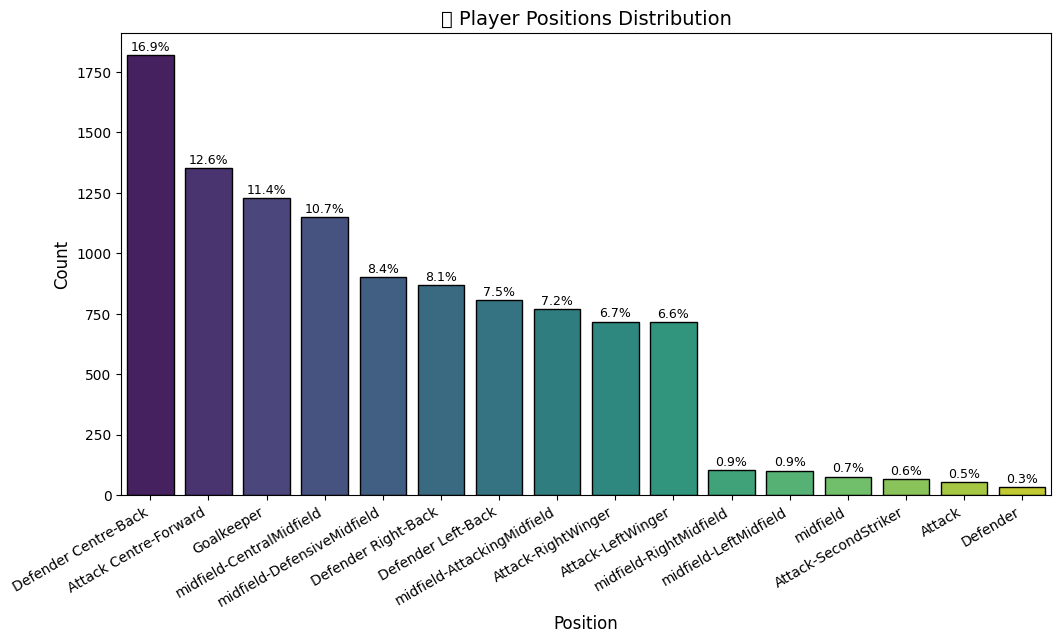

In [123]:
# Set figure size for better visualization
plt.figure(figsize=(12, 6))
position_counts = football["position"].value_counts()

# Create the bar chart
sns.barplot(x=position_counts.index, y=position_counts.values, order=position_counts.index, palette="viridis", edgecolor="black")
plt.xlabel("Position", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("🔹 Player Positions Distribution", fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Add percentage labels above bars
for i, v in enumerate(position_counts.values):
    plt.text(i, v + 20, f"{(v / football.shape[0]) * 100:.1f}%", ha='center', fontsize=9, color="black")

# Show the plot
plt.show()



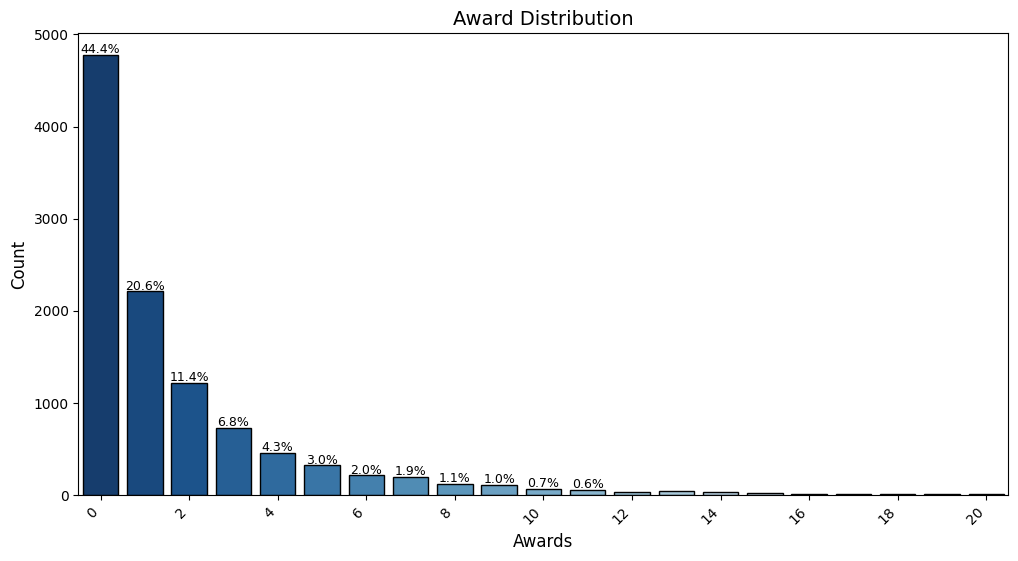

In [124]:
# Set figure size
plt.figure(figsize=(12, 6))

# Get award counts
award_counts = football["award"].value_counts().sort_index()

# Limit x-axis to a reasonable range (e.g., first 20 awards)
max_award_to_show = 20  # Adjust if needed
filtered_award_counts = award_counts[award_counts.index <= max_award_to_show]

# Create the bar chart
sns.barplot(x=filtered_award_counts.index, y=filtered_award_counts.values, palette="Blues_r", edgecolor="black")
plt.xlabel("Awards", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Award Distribution", fontsize=14)

# Adjust x-axis labels (show every 2nd or 5th label to avoid clutter)
plt.xticks(ticks=filtered_award_counts.index[::2], labels=filtered_award_counts.index[::2], rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Add percentage labels above bars
for i, v in enumerate(filtered_award_counts.values):
    if v > 50:  # Display only for significant values to avoid clutter
        plt.text(i, v + 20, f"{(v / football.shape[0]) * 100:.1f}%", ha='center', fontsize=9, color="black")

# Show the plot
plt.show()



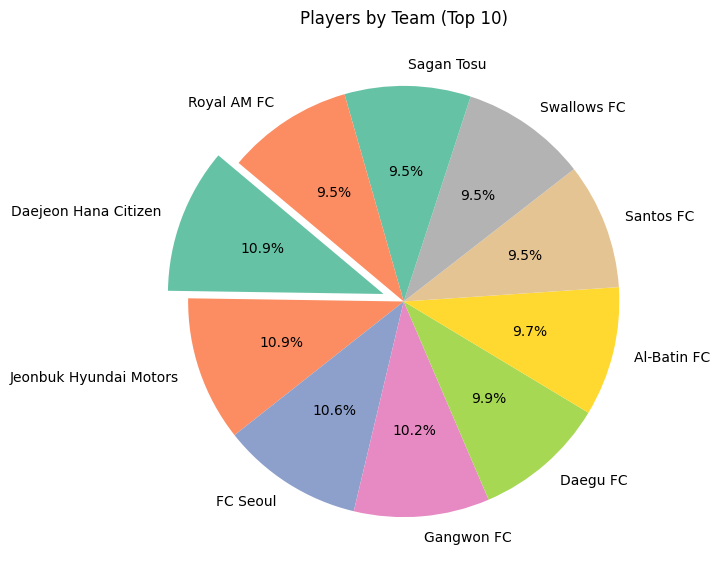

In [125]:
plt.figure(figsize=(7, 7))
top_teams = football["team"].value_counts().nlargest(10)
explode = [0.1] + [0] * 9  # Explode only the first slice for emphasis
plt.pie(top_teams, labels=top_teams.index, autopct="%1.1f%%", colors=sns.color_palette("Set2", len(top_teams)), startangle=140, explode=explode)
plt.title("Players by Team (Top 10)")
plt.show()


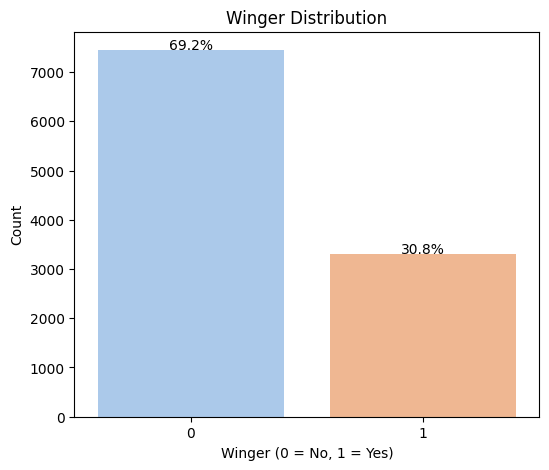

In [126]:
plt.figure(figsize=(6, 5))
winger_counts = football["winger"].value_counts()
sns.barplot(x=winger_counts.index, y=winger_counts.values, palette="pastel")
plt.xlabel("Winger (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Winger Distribution")

# Add percentage labels
for i, v in enumerate(winger_counts.values):
    plt.text(i, v + 5, f"{(v / football.shape[0]) * 100:.1f}%", ha='center')

plt.show()


#### II. Numerical Variables:

we need to understand the central tendency and spread of the variable (Descriptive Analysis) using:
   - Box plot
   - Histogram

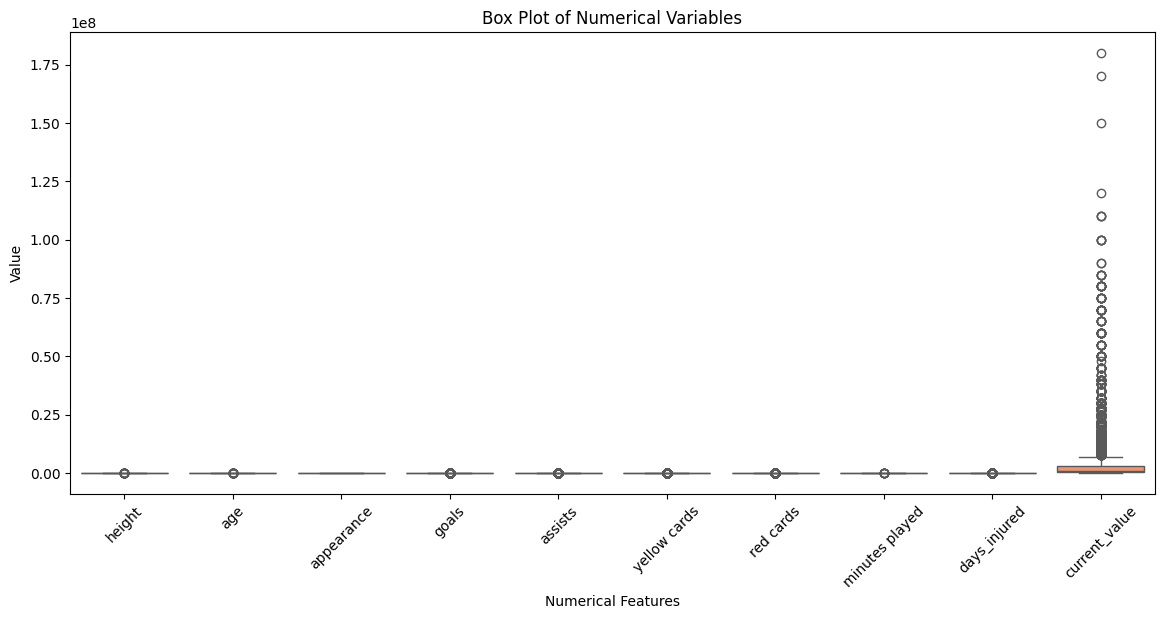

In [127]:
# Define numerical columns
numerical_columns = ["height", "age", "appearance", "goals", "assists",
                     "yellow cards", "red cards", "minutes played",
                     "days_injured", "current_value"]

# Set figure size
plt.figure(figsize=(14, 6))

# Create Box Plot
sns.boxplot(data=football[numerical_columns], palette="Set2")
plt.xticks(rotation=45)  # Rotate x labels for better visibility
plt.title("Box Plot of Numerical Variables")
plt.ylabel("Value")
plt.xlabel("Numerical Features")

# Show plot
plt.show()


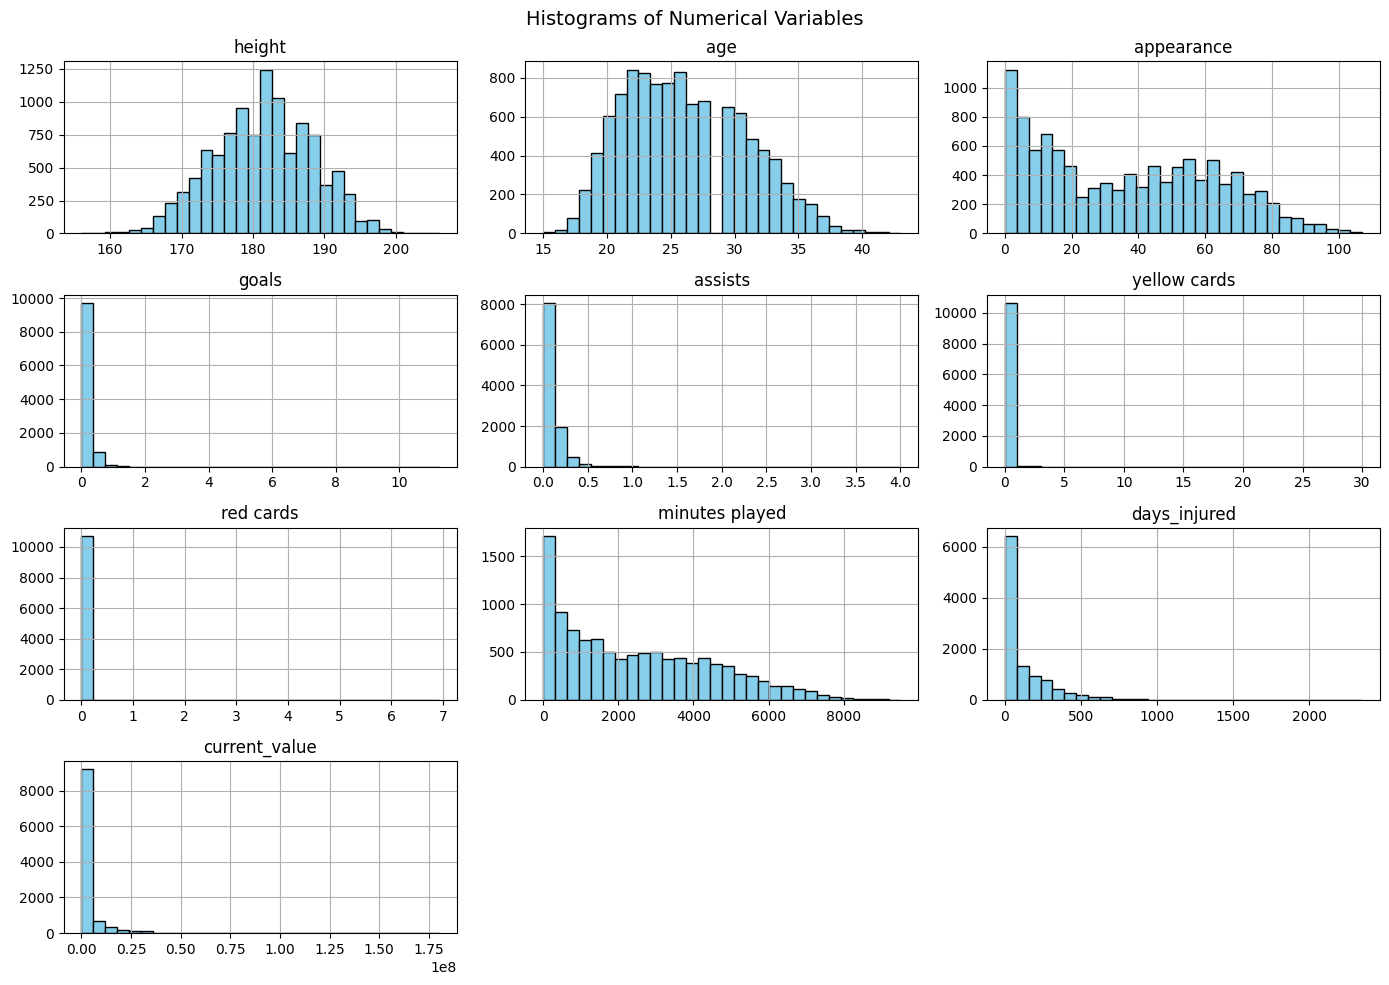

In [128]:
# Set figure size
football[numerical_columns].hist(figsize=(14, 10), bins=30, color="skyblue", edgecolor="black")

# Adjust layout for better spacing
plt.suptitle("Histograms of Numerical Variables", fontsize=14)
plt.tight_layout()

# Show plot
plt.show()


### 2. Univariate Non-Graphical analysis:

- Where is the center of the data? (location) --> **Measures of central tendency**
- How much does the data vary? (scale) --> **Measure of variability**
- What is the shape of the data? (shape) --> **Measures of variation combined with an average (measure of center) gives a good picture of the distribution of the data.**

In [129]:

numeric_columns = football.select_dtypes(include=['float64', 'int64'])


statistics = pd.DataFrame({
    'Mean': numeric_columns.mean(),
    'Median': numeric_columns.median(),
    'Mode': numeric_columns.mode().iloc[0],
    'Range': numeric_columns.max() - numeric_columns.min(),
    'Std Dev': numeric_columns.std(),
    'Variance': numeric_columns.var(),
    'Skewness': numeric_columns.skew(),
})


print(statistics)


                             Mean        Median       Mode         Range  \
height               1.812404e+02  1.812404e+02      180.0  5.000000e+01   
age                  2.604190e+01  2.600000e+01       22.0  2.800000e+01   
appearance           3.640701e+01  3.500000e+01        0.0  1.070000e+02   
goals                1.255543e-01  4.596918e-02        0.0  1.125000e+01   
assists              8.697765e-02  4.077323e-02        0.0  4.000000e+00   
yellow cards         1.897572e-01  1.502504e-01        0.0  3.000000e+01   
second yellow cards  4.665667e-03  0.000000e+00        0.0  1.000000e+00   
red cards            6.826070e-03  0.000000e+00        0.0  6.923077e+00   
goals conceded       1.316555e-01  0.000000e+00        0.0  9.000000e+00   
clean sheets         4.488090e-02  0.000000e+00        0.0  9.000000e+01   
minutes played       2.470789e+03  2.101500e+03        0.0  9.510000e+03   
days_injured         1.179617e+02  3.700000e+01        0.0  2.349000e+03   
games_injure

In [130]:
### Key Insights from the Data:
# - Player Age: Avg 26.04 years, typical for professional players.
# - Height: Avg 181.24 cm, standard for footballers.
# - Minutes Played: High variance (Std Dev = 2021.70), big gap between starters and reserves.
# - Goals & Assists: Highly skewed (Skewness = 14.26, 7.35), few top scorers, most players contribute little.
# - Red Cards: Extremely skewed (Skewness = 63.31), most players have none, a few get many.
# - Injuries: Large variation (Range = 2349 days), some rarely injured, others miss seasons.
# - Clean Sheets: Highly skewed (Skewness = 87.39), only a few goalkeepers have many.

## 4. Bivariate/Multivariate Analysis:

Here, you look at the relationships between two or more variables. This can involve looking for correlations, patterns, and trends that suggest a relationship or an association.

We can perform bi-variate analysis for any combination of categorical and numerical variables. The combination can be:
| bi-variate variables   | Plot type |
| ------------- | ------------- |
| Categorical & Categorical| Stacked Bar Chart |
| Categorical & numerical  | scatter plot, histogram, box plot|
| numerical  & numerical  | Scatter plot, line chart|


Multivariate Analysis:
- Heat map
- Bar Chart
- Scatter Chart
- Line Chart

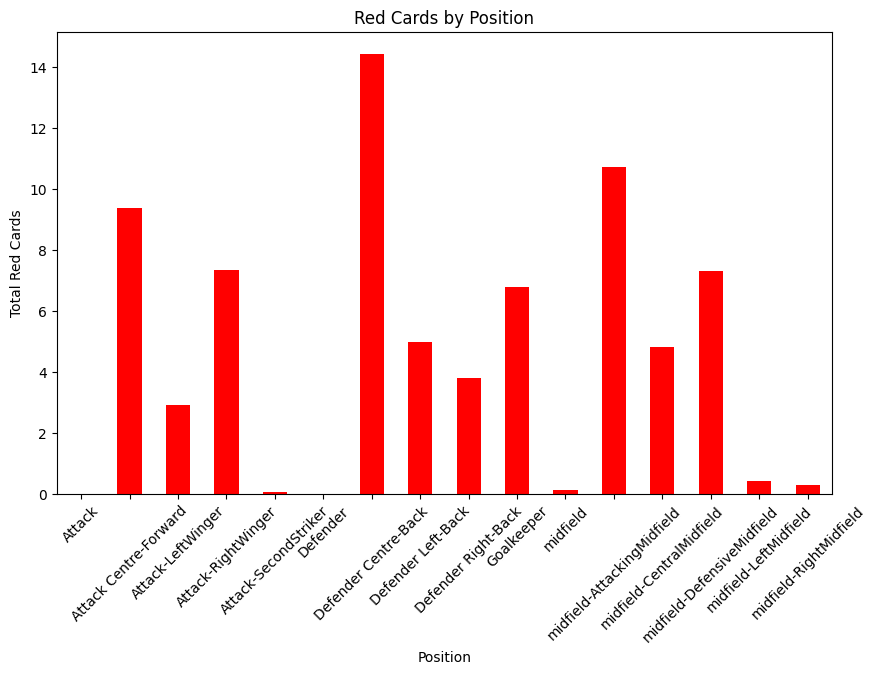

In [131]:
plt.figure(figsize=(10, 6))
position_red_cards = football.groupby("position")["red cards"].sum()
position_red_cards.plot(kind="bar", color="red")
plt.xlabel("Position")
plt.ylabel("Total Red Cards")
plt.title("Red Cards by Position")
plt.xticks(rotation=45)
plt.show()


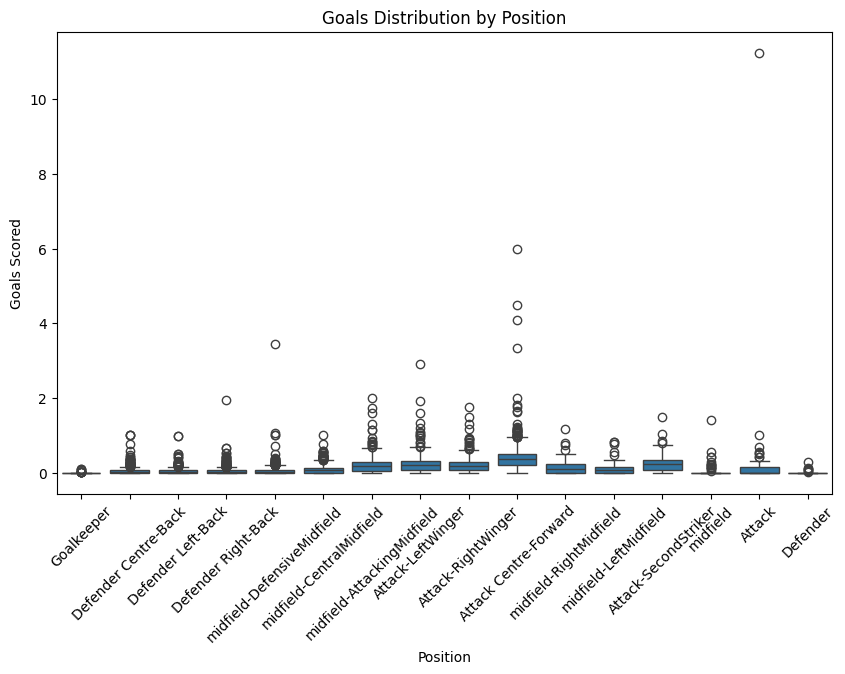

In [132]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="position", y="goals", data=football)
plt.xlabel("Position")
plt.ylabel("Goals Scored")
plt.title("Goals Distribution by Position")
plt.xticks(rotation=45)
plt.show()


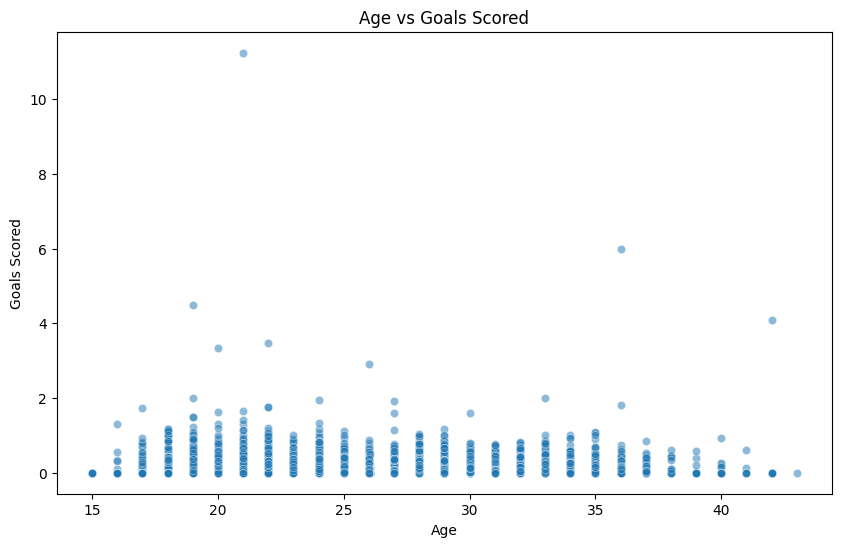

In [133]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=football["age"], y=football["goals"], alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Goals Scored")
plt.title("Age vs Goals Scored")
plt.show()


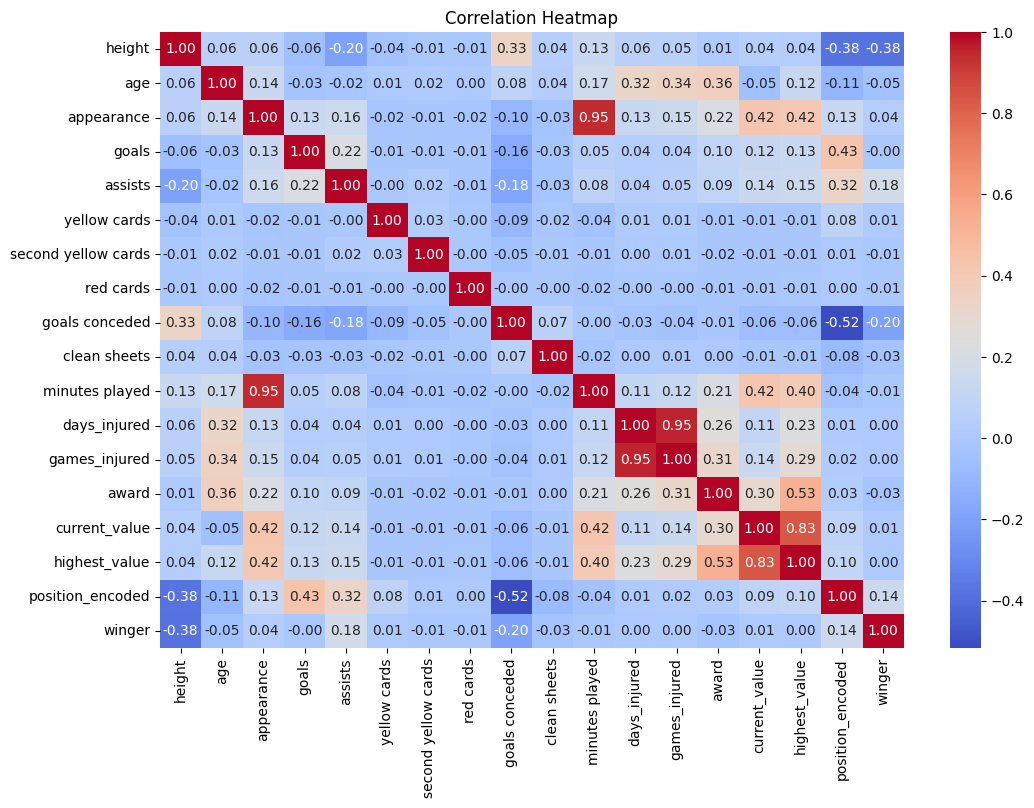

In [134]:

numeric_df = football.select_dtypes(include=["number"])


plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()



### Test Dbscan 

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors


In [153]:
selected_features = ['appearance', 'minutes played', 'highest_value']

In [156]:
# Define which features are numeric and which are categorical
numeric_features = ['minutes played', 'highest_value','appearance']

In [157]:
# Build a preprocessing pipeline: scale numeric features and one-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
    ]
)
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])


In [158]:
# Apply preprocessing
X_processed = pipeline.fit_transform(X)

In [197]:
# --- Step 1: Calculate the k-distance graph ---
min_samples = 3  # Minimum number of points to form a dense region
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_processed)
distances, indices = nn.kneighbors(X_processed)

In [198]:
# The distance to the min_samples-th nearest neighbor for each point
k_dist = distances[:, min_samples-1]

In [199]:
# Sort distances
k_dist_sorted = np.sort(k_dist)

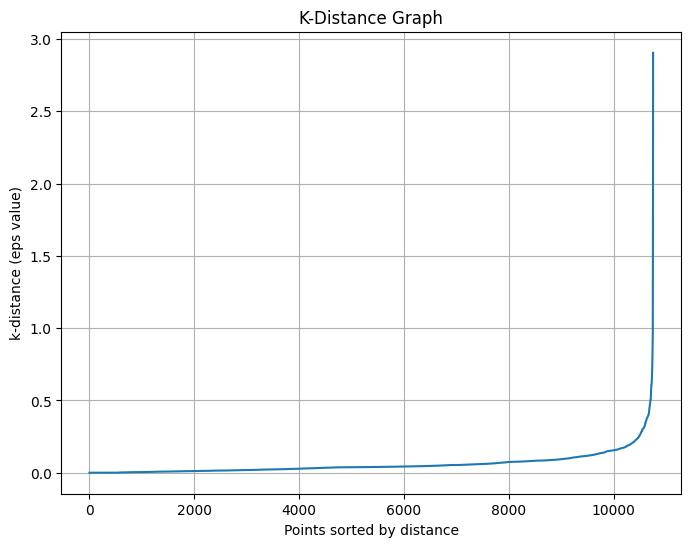

In [200]:
# Plot the k-distance graph
plt.figure(figsize=(8, 6))
plt.plot(k_dist_sorted)
plt.title('K-Distance Graph')
plt.xlabel('Points sorted by distance')
plt.ylabel('k-distance (eps value)')
plt.grid(True)
plt.show()

In [201]:
# --- Step 2: Choose eps from the k-distance graph ---
# After visually inspecting the k-distance graph, choose an appropriate eps value, e.g., at the "elbow"
chosen_eps = 0.5  # Example chosen value, update based on the k-distance graph

In [202]:
# --- Step 3: Apply DBSCAN with chosen eps ---
dbscan = DBSCAN(eps=chosen_eps, min_samples=min_samples, metric='euclidean')
final_labels = dbscan.fit_predict(X_processed)

In [203]:
# Add the cluster labels to the DataFrame
X['Cluster_DBSCAN'] = final_labels

In [204]:
# Display final clustering results for DBSCAN
print("DBSCAN Cluster Distribution:")
print(X['Cluster_DBSCAN'].value_counts())

DBSCAN Cluster Distribution:
Cluster_DBSCAN
 0    10691
-1       35
 1        4
 2        3
 3        3
 4        3
 8        3
 5        3
 7        3
 6        3
 9        3
Name: count, dtype: int64


In [205]:
# --- Step 4: Evaluate the clustering with Silhouette Score ---
# Calculate the silhouette score for the final clustering (only if there are at least 2 clusters)
unique_labels = np.unique(final_labels)
num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

if num_clusters >= 2:
    silhouette_avg = silhouette_score(X_processed, final_labels)
    print(f"Silhouette Score: {silhouette_avg}")
else:
    print("Silhouette score cannot be computed as there are fewer than 2 clusters.")


Silhouette Score: 0.4640132309648879


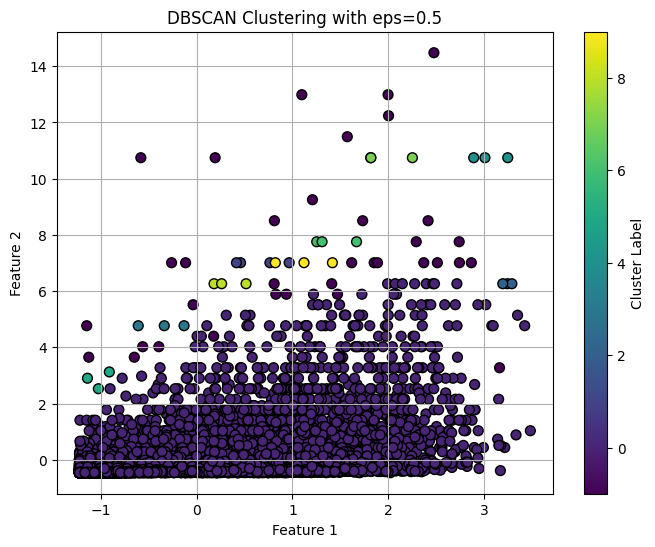

In [206]:
# Optional: Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_processed[:, 0], X_processed[:, 1], c=final_labels, cmap='viridis', s=50, edgecolor='k')
plt.title(f'DBSCAN Clustering with eps={chosen_eps}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()

### Final DBSCAN model

In [254]:
df.columns

Index(['player', 'team', 'name', 'position', 'height', 'age', 'appearance',
       'goals', 'assists', 'yellow cards', 'second yellow cards', 'red cards',
       'goals conceded', 'clean sheets', 'minutes played', 'days_injured',
       'games_injured', 'award', 'current_value', 'highest_value',
       'position_encoded', 'winger'],
      dtype='object')

In [243]:
df.dtypes

player                  object
team                    object
name                    object
position                object
height                 float64
age                    float64
appearance               int64
goals                  float64
assists                float64
yellow cards           float64
second yellow cards    float64
red cards              float64
goals conceded         float64
clean sheets           float64
minutes played           int64
days_injured             int64
games_injured            int64
award                    int64
current_value            int64
highest_value            int64
position_encoded         int64
winger                   int64
dtype: object

In [255]:
select_features = ['current_value', 'minutes played', 'appearance']

df =df[select_features]

In [256]:
df[(df['current_value'] <= 0.7 * 1e8) & (df['minutes played'] <= 8000)]

,current_value,minutes played,appearance
1,1500000,1304,15
2,600000,292,4
3,50000000,6408,82
4,40000000,5031,63
5,25000000,4762,68
...,...,...,...
10749,75000,1023,16
10750,300000,1449,26
10751,50000,960,20
10752,50000,865,17


In [257]:
df= df[(df['current_value'] <= 0.7 * 1e8) & (df['minutes played'] <= 8000)]

In [258]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score


# Selected Features
features = ['current_value', 'minutes played', 'appearance']

# Preprocessing Pipeline (treating position_encoded as a categorical feature and applying OneHotEncoder)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), features),  # Scaling for numerical columns
        # Add OneHotEncoder for categorical columns if needed
    ]
)

pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Apply transformations
X_preprocessed = pipeline.fit_transform(df)  # Apply transformations on the whole dataset

# -------------------------------------------------------------------
# Hyperparameter tuning for DBSCAN
# -------------------------------------------------------------------
eps_values = [1, 0.8, 0.9, 0.5]  # Fine-tuned eps values
min_samples_values = [3, 4, 5, 6, 7]  # More refined min_samples values

best_score = -1
best_params = None
results = []  # Store (eps, min_samples, n_clusters, silhouette_score)

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_preprocessed)

        # Count clusters (excluding noise labeled as -1)
        unique_labels = set(labels) - {-1}
        n_clusters = len(unique_labels)

        # Only compute silhouette if there are at least 2 clusters
        if n_clusters > 1:
            score = silhouette_score(X_preprocessed, labels)
        else:
            score = -1  # Invalid scenario

        results.append((eps, min_samples, n_clusters, score))

        # Track the best performing params
        if score > best_score:
            best_score = score
            best_params = (eps, min_samples)

# Print the best result
if best_params is not None:
    print(f"Best Silhouette Score: {best_score:.4f}")
    print(f"Best eps, min_samples: {best_params}")
else:
    print("No valid clustering (with >=2 clusters) found in given parameter ranges.")

# -------------------------------------------------------------------
# View all results in a DataFrame
# -------------------------------------------------------------------
df_results = pd.DataFrame(results, columns=["eps", "min_samples", "n_clusters", "silhouette_score"])
df_results = df_results.sort_values(by="silhouette_score", ascending=False)
print(df_results)

# -------------------------------------------------------------------
# Apply DBSCAN with best parameters
# -------------------------------------------------------------------
if best_params:
    best_eps, best_min_samples = best_params
    final_dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
    final_labels = final_dbscan.fit_predict(X_preprocessed)

    # Merge cluster labels with original DataFrame
    df_processed = df.copy()
    df_processed['Cluster'] = final_labels

    # Cluster distribution
    print("Cluster Distribution:\n", df_processed['Cluster'].value_counts())


Best Silhouette Score: 0.8154
Best eps, min_samples: (1, 3)
    eps  min_samples  n_clusters  silhouette_score
0   1.0            3           9          0.815380
1   1.0            4           9          0.815380
14  0.9            7           8          0.815380
13  0.9            6           9          0.815380
12  0.9            5           9          0.815380
11  0.9            4           9          0.815380
10  0.9            3           9          0.815380
4   1.0            7           8          0.815380
3   1.0            6           9          0.815380
2   1.0            5           9          0.815380
6   0.8            4          13          0.792145
5   0.8            3          13          0.792145
7   0.8            5          12          0.791901
8   0.8            6          11          0.791213
9   0.8            7          10          0.791067
15  0.5            3          14          0.778812
16  0.5            4          13          0.778453
17  0.5            5  

In [261]:
df

,current_value,minutes played,appearance
1,1500000,1304,15
2,600000,292,4
3,50000000,6408,82
4,40000000,5031,63
5,25000000,4762,68
...,...,...,...
10749,75000,1023,16
10750,300000,1449,26
10751,50000,960,20
10752,50000,865,17


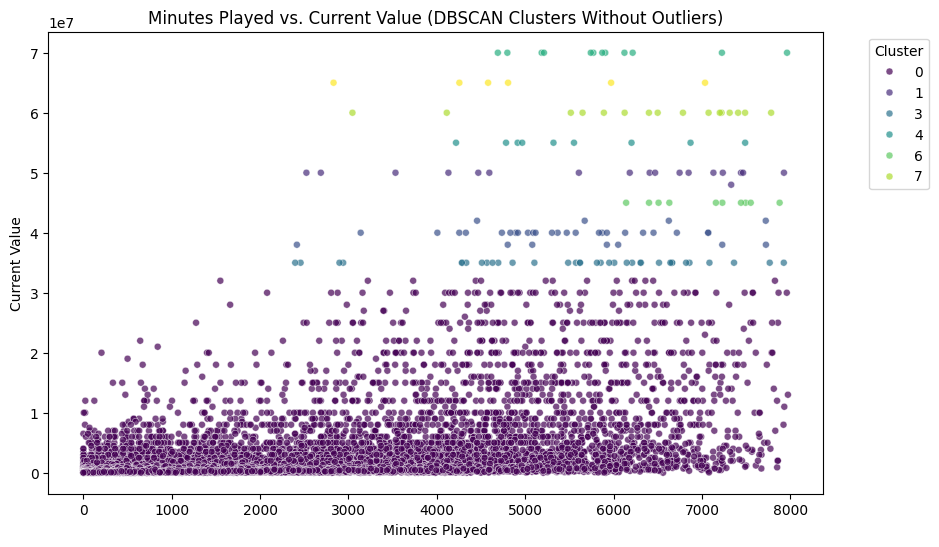

In [263]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_processed, x='minutes played', y='current_value', 
                hue=df_processed['Cluster'], palette='viridis', alpha=0.7, s=25)

plt.title('Minutes Played vs. Current Value (DBSCAN Clusters Without Outliers)')
plt.xlabel('Minutes Played')
plt.ylabel('Current Value')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


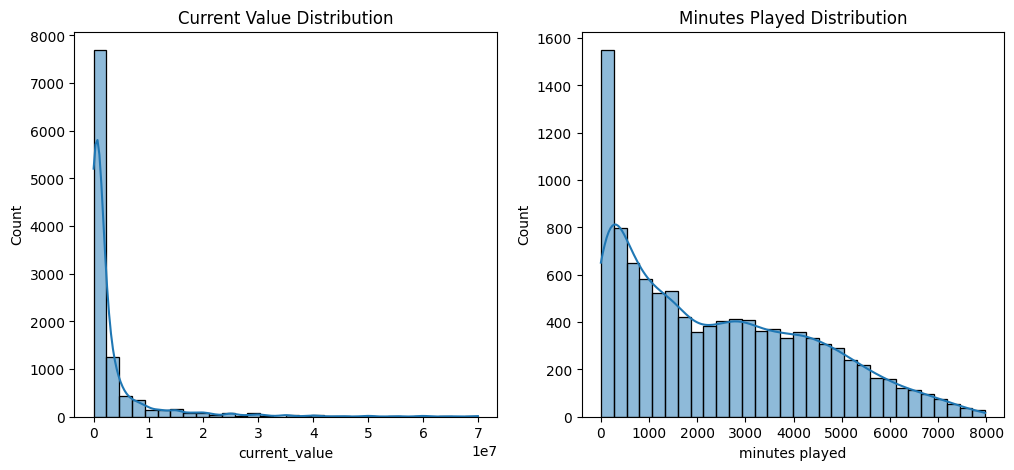

In [264]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['current_value'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Current Value Distribution')
sns.histplot(df['minutes played'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Minutes Played Distribution')
plt.show()



In [265]:
final_labels = df_processed['Cluster']

In [266]:
final_labels

1        0
2        0
3        1
4        2
5        0
        ..
10749    0
10750    0
10751    0
10752    0
10753    0
Name: Cluster, Length: 10673, dtype: int64

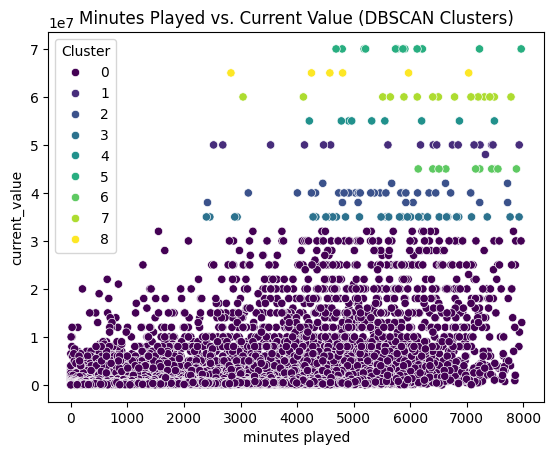

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df_processed, x='minutes played', y='current_value', hue=final_labels, palette='viridis', legend='full')
plt.title('Minutes Played vs. Current Value (DBSCAN Clusters)')

plt.show()


In [ ]:
import plotly.express as px

fig = px.scatter_3d(df, 
                    x='current_value', 
                    y='minutes played', 
                    z='appearance',
                    color=df_processed['Cluster'])  

fig.show()


In [274]:
classZero=df_processed[df_processed['Cluster']==0]
pd.set_option('display.max_rows', None)
classZero.max()

current_value     32000000
minutes played        7973
appearance             104
Cluster                  0
dtype: int64

In [275]:
classZero=df_processed[df_processed['Cluster']==0]
pd.set_option('display.max_rows', None)
classZero.min()

current_value     0
minutes played    0
appearance        0
Cluster           0
dtype: int64


1. **Cluster 0: "Mixed Performance and Value"** – A wide range of both player performance (minutes played, appearances) and market value.
2. **Cluster 1: "Key Contributors"** – High minutes and appearances, essential to the team.
3. **Cluster 2: "Reliable Contributors"** – Consistent, dependable players with solid playing time.
4. **Cluster 3: "Rotational Players"** – Varied playing time, likely rotated in and out.
5. **Cluster 4: "Consistent Contributors"** – Steady performers with regular playing time.
6. **Cluster 5: "High-Value Contributors"** – High market value, significant contributions.
7. **Cluster 6: "Elite Contributors"** – Top performers with high playing time and value.
8. **Cluster 7: "Valuable Contributors"** – Important players with good minutes and value.
9. **Cluster 8: "Emerging Talents"** – High potential, but less consistent playing time.


In [ ]:
class_names = {0: 'Mixed Performance and Value', 1: 'Key Contributors', 2: 'Reliable Contributors' , 3:'Rotational Players',4:'Consistent Contributors',5:'High-Value Contributors',6:'Elite Contributors',7:'Valuable Contributors',8:'Emerging Talents'}

df_processed['Cluster'] = df_processed['Cluster'].map(class_names)

In [278]:
dbscan_cluster = df_processed['Cluster']

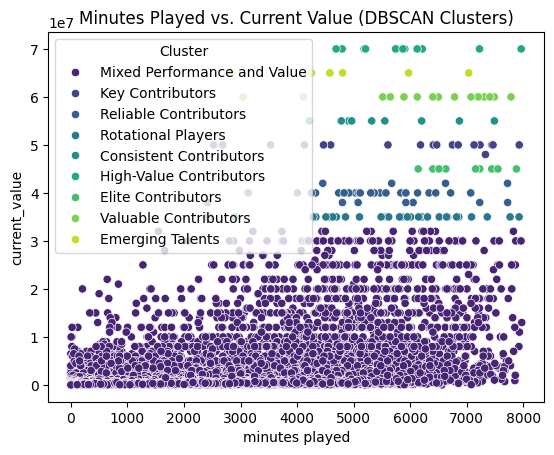

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df_processed, x='minutes played', y='current_value', hue=dbscan_cluster, palette='viridis', legend='full')
plt.title('Minutes Played vs. Current Value (DBSCAN Clusters)')

# Show the plot
plt.show()
